### Multimodal
- Text, Image, Audio, Video

In [2]:
# version check
!pip --version

pip 26.2.1 from C:\pkh20260902\ex0914\.venv\Lib\site-packages\pip (python 3.12)



In [4]:
from langchain_teddynote.models import MultiModal
from langchain_teddynote.messages import stream_response
from langchain_openai import ChatOpenAI

In [5]:
import base64
from pathlib import Path

from langchain_core.messages import HumanMessage, SystemMessage

In [6]:
# 객체 생성
llm = ChatOpenAI(
    temperature=0.1,
    model="gpt-4o-mini"
)

In [7]:
def image_url(image_source):
    """Convert a local imag path to a data URL; keep HTTP URLs unchanged."""
    if str(image_source).startswith (("http://", "https://")):
        return str(image_source)

    image_path = Path(image_source)
    mime_type = "image/png" if image_path.suffix.lower() == ".png" else "image/jpeg"
    encoded_image = base64.b64encode(image_path.read_bytes()).decode("utf-8")
    return f"data:{mime_type};base64,{encoded_image}"

def stream_image_response(image_source, user_prompt, system_prompt=None):
    content = [
        {"type": "text", "text": user_prompt},
        {"type": "image_url", "image_url": {"url": image_url(image_source)}},
         
    ]
    messages = [HumanMessage(content=content)]
    if system_prompt:
        messages.insert(0, SystemMessage(content=system_prompt))

    for token in llm.stream(messages):
        print(token.content, end="", flush=True)
    print()

In [8]:
# 멀티모달 객체 생성
multimodal_llm = MultiModal(llm)


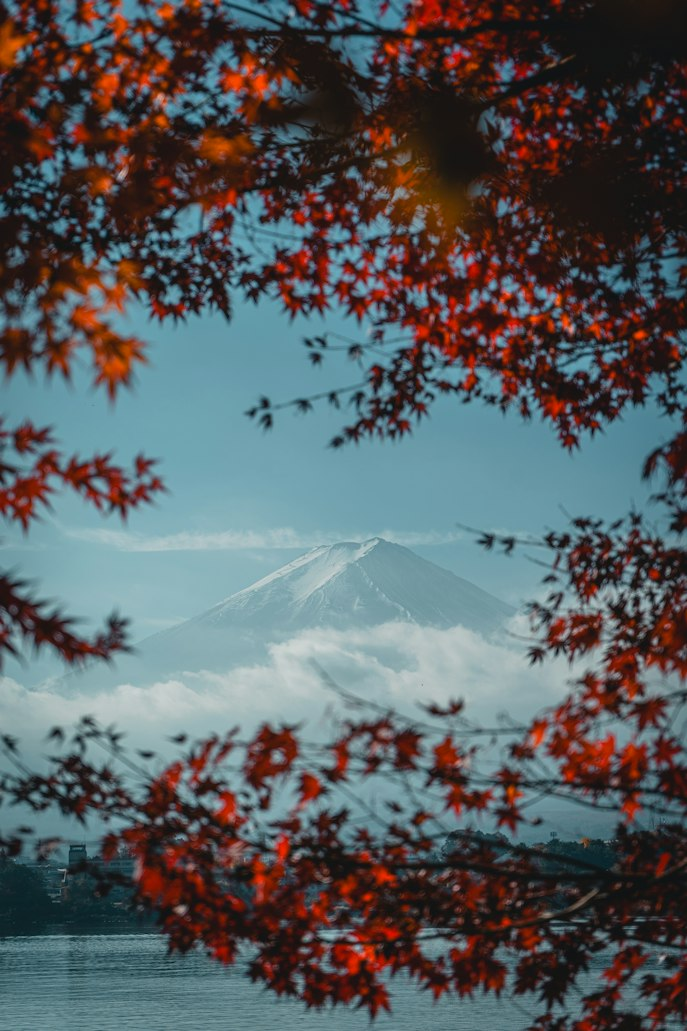

The image captures a stunning landscape featuring a prominent mountain, likely Mount Fuji, framed by vibrant red autumn leaves. 

### Composition:
- **Foreground**: The red leaves create a natural frame, drawing the viewer's eye toward the mountain in the background. This use of framing adds depth and context to the scene.
- **Background**: The mountain stands majestically, partially shrouded in clouds, with a snow-capped peak that contrasts beautifully against the blue sky. The clouds add a sense of mystery and grandeur.

### Color Palette:
- **Warm Tones**: The red leaves introduce warm hues, suggesting the season of autumn. This warmth contrasts with the cooler tones of the mountain and sky.
- **Cool Tones**: The blue sky and white clouds provide a serene backdrop, enhancing the overall tranquility of the scene.

### Atmosphere:
- The image evokes a sense of peace and natural beauty, typical of Japanese landscapes. The combination of the vibrant foliage and the iconic mountain creat

In [9]:
# PG 99
IMAGE_URL = "https://images.unsplash.com/photo-1787662366208-b2c9a5b18462?q=80&w=687&auto=format&fit=crop&ixlib=rb-4.1.0&ixid=M3wxMjA3fDB8MHxwaG90by1wYWdlfHx8fGVufDB8fHx8fA%3D%3D"

# 이미지 파일로 부터 질의
answer = multimodal_llm.stream(IMAGE_URL)
stream_response(answer)

In [10]:
# 샘플 이미지 주소 (웹사이트로 부터 바로 인식)
IMAGE_URL = "https://images.unsplash.com/photo-1787662366208-b2c9a5b18462?q=80&w=687&auto=format&fit=crop&ixlib=rb-4.1.0&ixid=M3wxMjA3fDB8MHxwaG90by1wYWdlfHx8fGVufDB8fHx8fA%3D%3D"

# 이미지 파일로 부터 질의
stream_image_response(
    IMAGE_URL,
    "Please describe the image",
)

The image features a scenic view of a mountain, likely a volcano, partially shrouded in clouds. The foreground is framed by vibrant red and orange autumn leaves, creating a striking contrast against the blue sky. The mountain's peak is capped with snow, and the overall composition evokes a sense of tranquility and natural beauty. The colors of the leaves suggest that the photo was taken during the fall season, enhancing the picturesque quality of the landscape.


In [11]:
# PG 101. 시스템 프롬프트와 사용자 프롬프트 지정하기
system_prompt = "You are a very experienced photographer. Your task is to explain the features of the photo"

user_prompt = """Please explain the interesting features"""

In [ ]:
IMAGE_PATH_FROM_FILE = "https://images.unsplash.com/photo-1789009666152-ac554305c90b?q=80&w=687&auto=format&fit=crop&ixlib=rb-4.1.0&ixid=M3wxMjA3fDB8MHxwaG90by1wYWdlfHx8fGVufDB8fHx8fA%3D%3D"

# 이미지로 부터 질의
stream_image_response(
    IMAGE_PATH_FROM_FILE,
    user_prompt,
    system_prompt,
)

This photograph captures a beautiful autumn scene with several interesting features:

1. **Subject and Composition**: The main subject is a person holding a vibrant orange leaf, which draws the viewer's attention. The positioning of the leaf in front of the subject's face creates a playful and engaging focal point.

2. **Depth of Field**: The background is softly blurred, creating a bokeh effect that enhances the subject. This technique helps to isolate the person and the leaf, making them stand out against the warm, autumnal colors of the background.

3. **Color Palette**: The warm tones of the leaf and the surrounding foliage evoke a sense of fall. The contrast between the orange leaf and the muted colors of the subject's clothing adds visual interest.

4. **Lighting**: The natural light appears soft and diffused, likely indicating a golden hour setting. This type of lighting enhances the warmth of the colors and adds a gentle glow to the scene.

5. **Fashion Elements**: The subject'